In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv(r'C:\Users\User\Foundation of machine learning project\Foundation-of-Machine-Learning-assignment\AUTOMPG.csv')
df.head()

,Unnamed: 0,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,0,307.0,8,130.0,3504,12.0,70,1,18.0
1,1,350.0,8,165.0,3693,11.5,70,1,15.0
2,2,318.0,8,150.0,3436,11.0,70,1,18.0
3,3,304.0,8,150.0,3433,12.0,70,1,16.0
4,4,302.0,8,140.0,3449,10.5,70,1,17.0


In [6]:
#data inspections 
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
     

(398, 9)
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    398 non-null    int64  
 1   displacement  398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   mpg           398 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.1 KB
None
       Unnamed: 0  displacement   cylinders  horsepower       weight  \
count  398.000000    398.000000  398.000000  392.000000   398.000000   
mean   198.500000    193.425879    5.454774  104.469388  2970.424623   
std    115.036951    104.269838    1.701004   38.491160   846.841774   
min      0.000000     68.000000    3.000000   46.000000  1613.000000   
25%     9

In [ ]:
#data cleaning
#remove unnamed columns
x = df.drop(['Unnamed: 0', 'mpg'], axis=1)
y = df['mpg']


In [ ]:
df['horsepower'].isnull().sum() # the output says there are 6 null values so we fill them with the medians 

np.int64(6)

In [25]:
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())

In [49]:
df['horsepower'].isnull().sum()

np.int64(0)

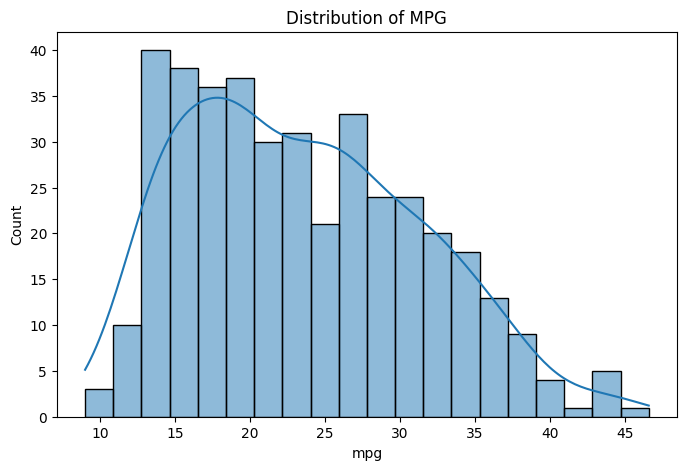

In [ ]:
#exploratory data analysis
#distribution of the data(skewed or normal distribution)
plt.figure(figsize=(8,5))
sns.histplot(df["mpg"], bins=20, kde=True)
plt.title("Distribution of MPG")
plt.show()

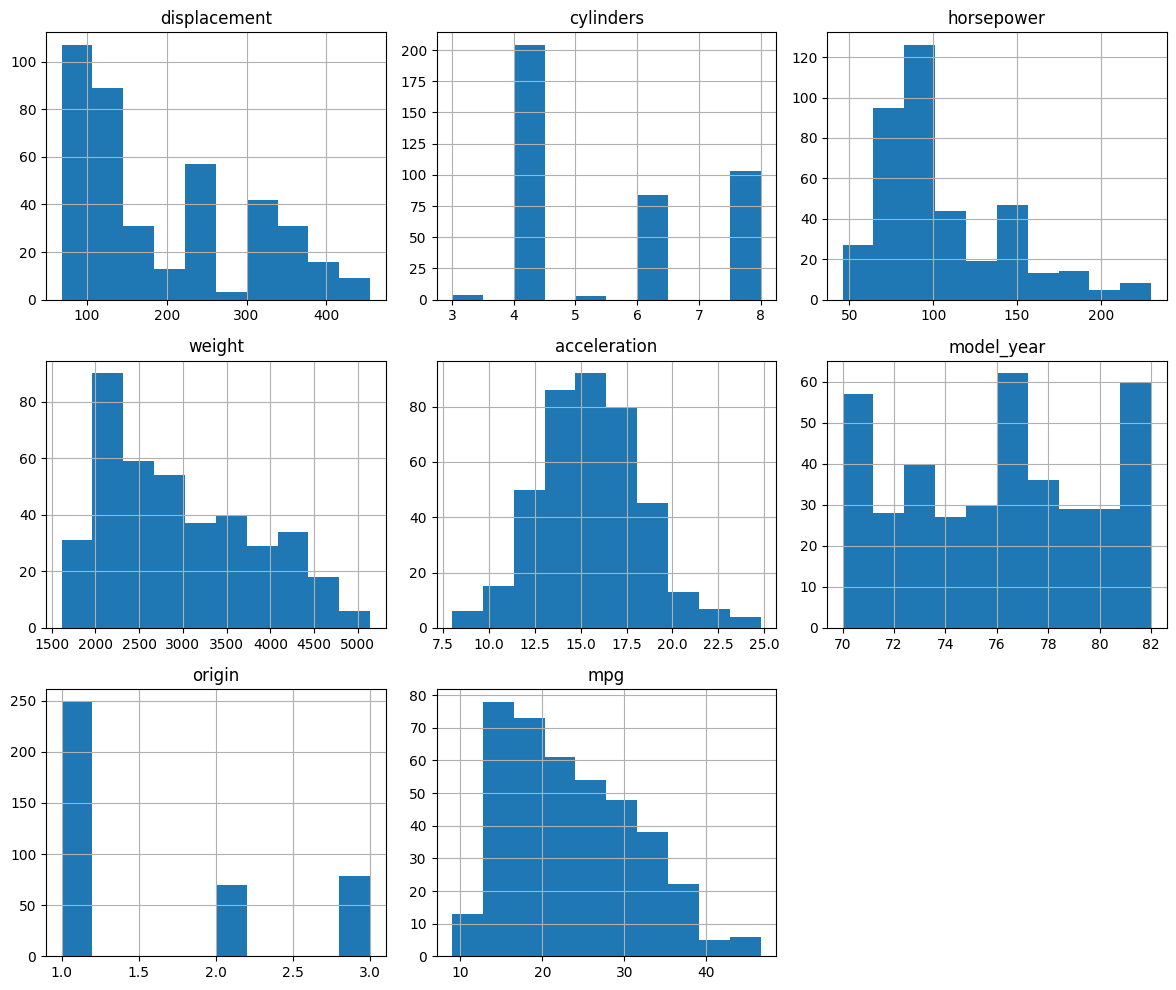

In [28]:
#feature distribution
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

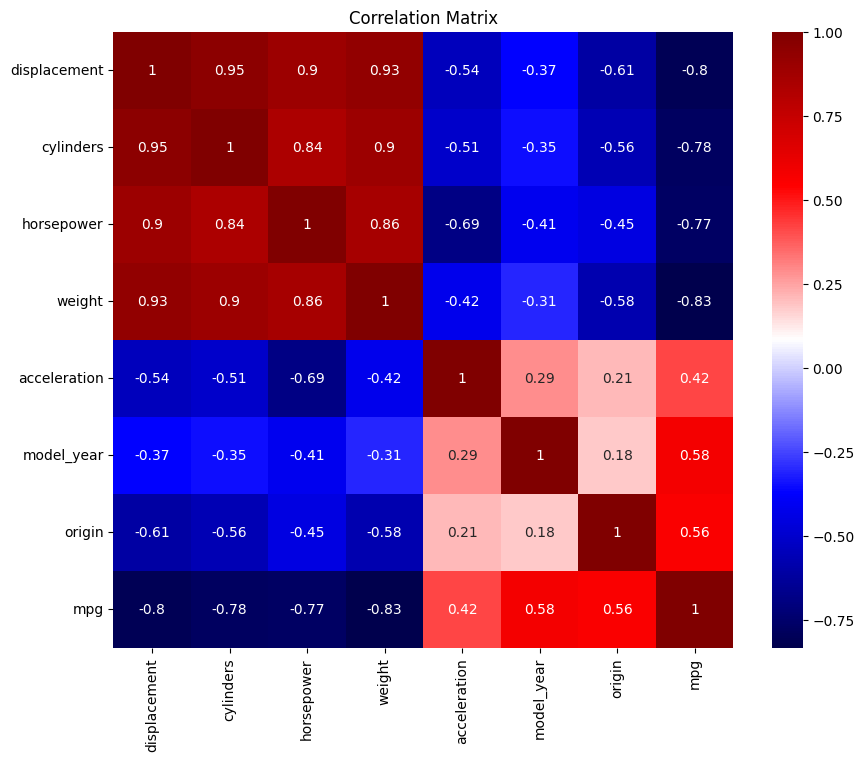

In [35]:
#correlation matrix
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='seismic'
)

plt.title("Correlation Matrix")
plt.show()

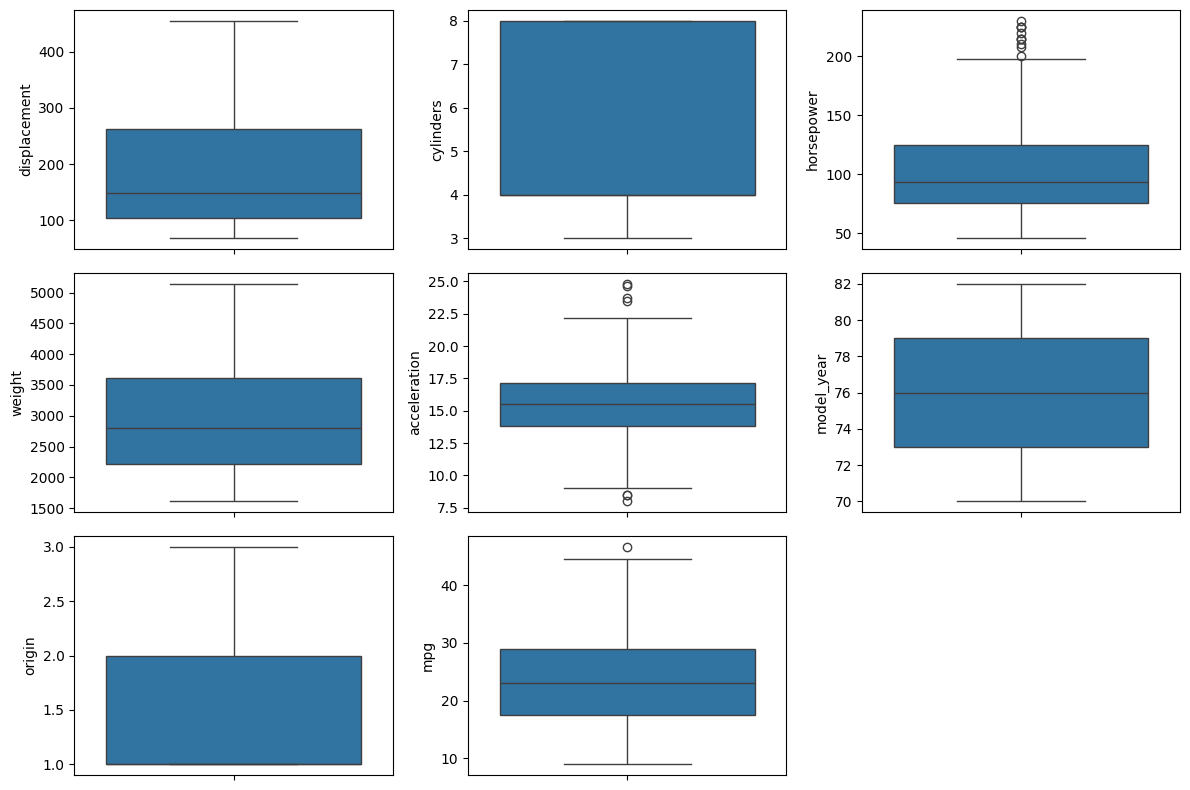

In [36]:
#outlier analysis
plt.figure(figsize=(12,8))

for i,col in enumerate(df.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

In [38]:
#train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [42]:
#first ML model random forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [43]:
#predict
y_pred_rf = rf.predict(x_test)

In [80]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print(f'MAE: {mae_rf}, RMSE: {rmse_rf}, R2: {r2_rf}')

MAE: 1.6313125, RMSE: 2.1882449103105435, R2: 0.9109404406628624


BUILD THE MLP

In [64]:
#build the mlp
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

Filling in the null values unders the hoursepower column

In [67]:
import numpy as np

print("NaNs in x_train_scaled:", np.isnan(x_train_scaled).sum())
print("NaNs in x_test_scaled:", np.isnan(x_test_scaled).sum())

NaNs in x_train_scaled: 5
NaNs in x_test_scaled: 1


In [68]:
from sklearn.impute import SimpleImputer

X = df.drop("mpg", axis=1)
y = df["mpg"]

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print(X.isnull().sum())

displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)


In [70]:
print(np.isnan(x_train_scaled).sum())
print(np.isnan(x_test_scaled).sum())

0
0


In [58]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(x),
    columns=x.columns
)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
# Train
mlp.fit(x_train_scaled, y_train)

# Prediction
y_pred_mlp = mlp.predict(x_test_scaled)

# Evaluate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)

mse_mlp = mean_squared_error(y_test, y_pred_mlp)

rmse_mlp = np.sqrt(mse_mlp)

r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Results")
print("MAE :", mae_mlp)
print("RMSE:", rmse_mlp)
print("R2  :", r2_mlp)

MLP Results
MAE : 1.6873925374429775
RMSE: 2.234138588516623
R2  : 0.9071656058208416


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


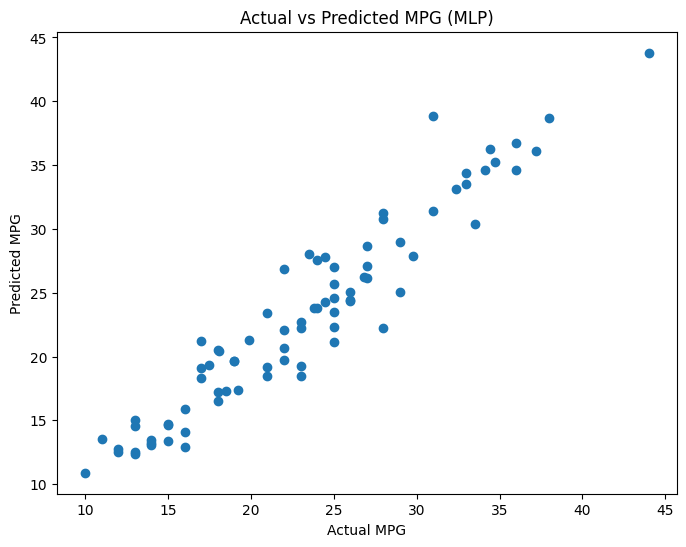

In [73]:
#plotting the actual vs the predicted 
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_mlp)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG (MLP)")
plt.show()

In [81]:
#linear regression model
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print('MAE:', mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

Linear Regression
MAE: 2.2553632612835726
MSE : 8.197746885825037
RMSE: 2.863170774827278
R2  : 0.8475304239212392


In [83]:
#create final results table 
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "MLP"],
    "MAE": [mae_lr, mae_rf, mae_mlp],
    "RMSE": [rmse_lr, rmse_rf, rmse_mlp],
    "R2": [r2_lr, r2_rf, r2_mlp]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,2.255363,2.863171,0.847530
1,Random Forest,1.631312,2.188245,0.910940
2,MLP,1.687393,2.234139,0.907166
